In [1]:
#Task 4 
print("Task 4")

Task 4


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

#Load Dataset
data = pd.read_csv(r'C:\Users\Hp\Downloads\insurance.csv')
print("Shape:", data.shape)
print(data.head())
print("\nData Types:\n", data.dtypes)
print("\nMissing Values:\n", data.isnull().sum())

Shape: (1338, 7)
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Data Types:
 age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing Values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [7]:
# ============================================================
# Step 2. CLEAN & PREPARE DATA
# ============================================================
# No missing values in this dataset, but good practice to check
data.dropna(inplace=True)

print("\nBasic Statistics:")
print(data.describe())




Basic Statistics:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [8]:

# ============================================================
# Step 3. ENCODE CATEGORICAL FEATURES
# ============================================================
le = LabelEncoder()

# Label Encode binary columns
data['sex']    = le.fit_transform(data['sex'])       # female=0, male=1
data['smoker'] = le.fit_transform(data['smoker'])    # no=0, yes=1

# One-Hot Encode 'region' (4 categories)
data = pd.get_dummies(data, columns=['region'], drop_first=True)

# Fix boolean dtype (pandas 2.x)
bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)

print("\nColumns after encoding:", data.columns.tolist())
print(data.head())


Columns after encoding: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']
   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400                 0   
1   18    1  33.770         1       0   1725.55230                 0   
2   28    1  33.000         3       0   4449.46200                 0   
3   33    1  22.705         0       0  21984.47061                 1   
4   32    1  28.880         0       0   3866.85520                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


C:\Users\Hp\AppData\Local\Temp\ipykernel_23472\3980199351.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_data, x='smoker', y='charges',


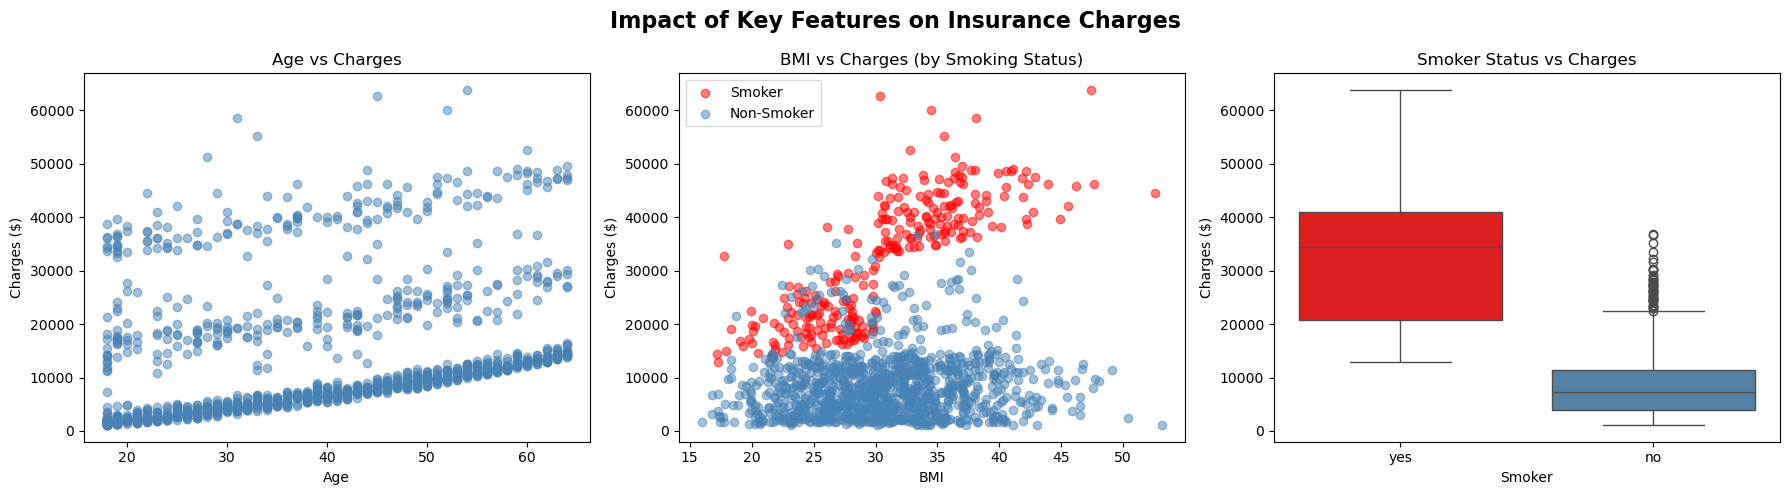

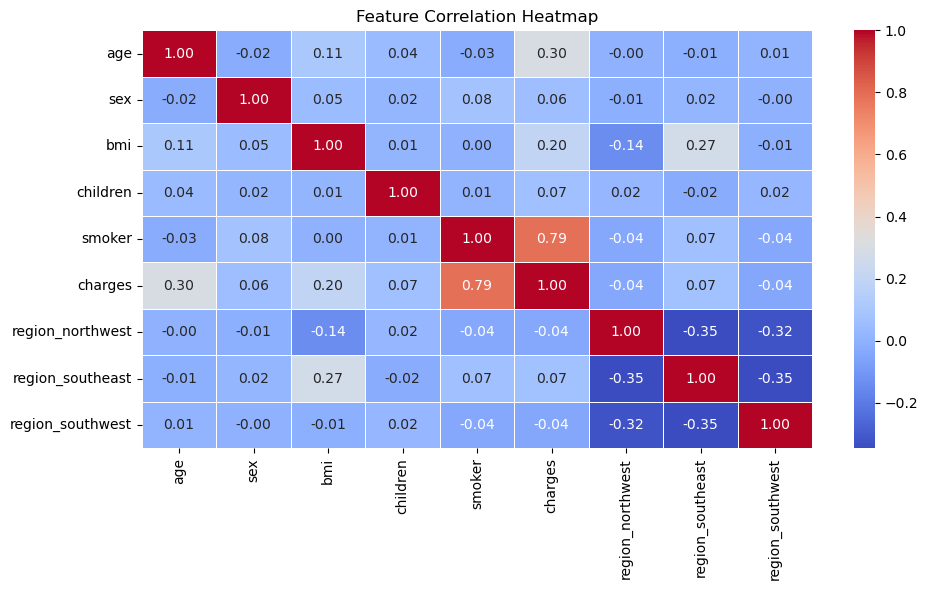

In [9]:
# ============================================================
# Step 4. VISUALIZATIONS — BMI, Age, Smoker vs Charges
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Impact of Key Features on Insurance Charges', fontsize=16, fontweight='bold')

# --- Plot 1: Age vs Charges ---
axes[0].scatter(data['age'], data['charges'], alpha=0.5, color='steelblue')
axes[0].set_title('Age vs Charges')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Charges ($)')

# --- Plot 2: BMI vs Charges (colored by smoker) ---
smokers    = data[data['smoker'] == 1]
non_smokers = data[data['smoker'] == 0]
axes[1].scatter(smokers['bmi'],     smokers['charges'],     alpha=0.5, color='red',       label='Smoker')
axes[1].scatter(non_smokers['bmi'], non_smokers['charges'], alpha=0.5, color='steelblue', label='Non-Smoker')
axes[1].set_title('BMI vs Charges (by Smoking Status)')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Charges ($)')
axes[1].legend()

# --- Plot 3: Smoker vs Charges (Boxplot) ---
original_data = pd.read_csv(r'C:\Users\Hp\Downloads\insurance.csv')   # reload for readable labels
sns.boxplot(data=original_data, x='smoker', y='charges',
            palette={'yes': 'red', 'no': 'steelblue'}, ax=axes[2])
axes[2].set_title('Smoker Status vs Charges')
axes[2].set_xlabel('Smoker')
axes[2].set_ylabel('Charges ($)')

plt.tight_layout()
plt.show()

# --- Correlation Heatmap ---
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()




In [10]:
# ============================================================
# Step 5. SPLIT FEATURES AND TARGET
# ============================================================
X = data.drop('charges', axis=1)
y = data['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTraining samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")




Training samples: 1070, Test samples: 268


In [11]:
# ============================================================
# Step 6. TRAIN LINEAR REGRESSION MODEL
# ============================================================
model = LinearRegression()
model.fit(X_train, y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
# ============================================================
# Step 7. EVALUATE MODEL — MAE & RMSE
# ============================================================
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = model.score(X_test, y_test)

print("\n========== MODEL EVALUATION ==========")
print(f"MAE  (Mean Absolute Error) : ${mae:,.2f}")
print(f"RMSE (Root Mean Sq. Error) : ${rmse:,.2f}")
print(f"R²   (Explained Variance)  : {r2:.4f}")




========== MODEL EVALUATION ==========
MAE  (Mean Absolute Error) : $4,181.19
RMSE (Root Mean Sq. Error) : $5,796.28
R²   (Explained Variance)  : 0.7836


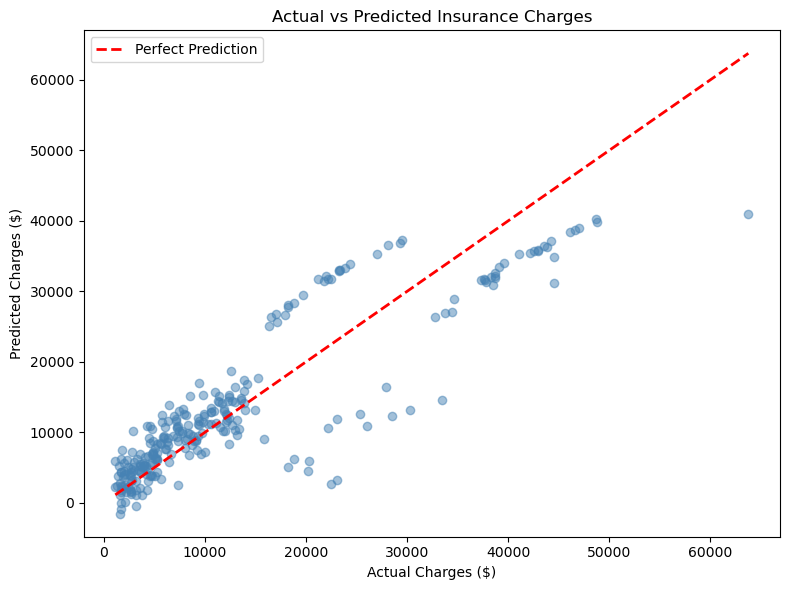

In [13]:
# ============================================================
#Step 8. ACTUAL vs PREDICTED PLOT
# ============================================================
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title('Actual vs Predicted Insurance Charges')
plt.legend()
plt.tight_layout()
plt.show()




Model Coefficients (impact on charges):
         Feature  Coefficient
          smoker 23651.128856
        children   425.278784
             bmi   337.092552
             age   256.975706
             sex   -18.591692
region_northwest  -370.677326
region_southeast  -657.864297
region_southwest  -809.799354


C:\Users\Hp\AppData\Local\Temp\ipykernel_23472\17988533.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coefficients, x='Coefficient', y='Feature',


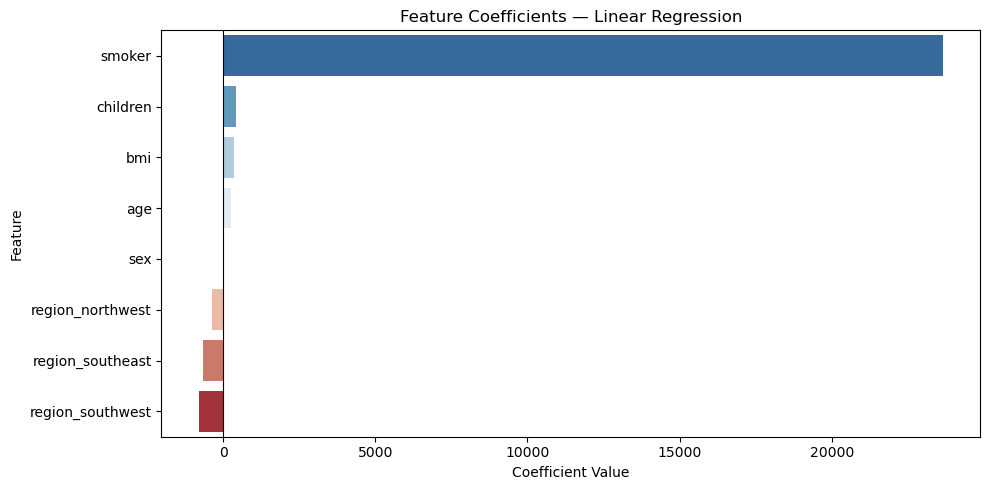

In [15]:
# ============================================================
# Step 9. FEATURE COEFFICIENTS (Linear Regression Interpretation)
# ============================================================
coefficients = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print("\nModel Coefficients (impact on charges):")
print(coefficients.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=coefficients, x='Coefficient', y='Feature',
            palette='RdBu_r')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients — Linear Regression')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

